# Gradient Descent

## Introduction
Gradient Descent is an **optimization algorithm** used in **machine learning and data science** to minimize a **cost (loss) function**.  
It works by **iteratively adjusting model parameters** in the direction that reduces the error.

---

## Why Gradient Descent is Needed
In machine learning models (like Linear Regression, Logistic Regression, Neural Networks), we define a **loss function** that measures how far the predicted output is from the actual output.  
Gradient Descent helps find the **optimal parameters** that minimize this loss.

---

## Basic Idea
- Start with **initial values** of parameters
- Compute the **gradient (slope)** of the loss function
- Move parameters in the **opposite direction of the gradient**
- Repeat until the loss is minimized

---

## Mathematical Representation
The parameter update rule is:

$$
J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2
$$

$$
\frac{\partial J(\theta)}{\partial \theta_j}
= \frac{1}{m} \sum_{i=1}^{m}
\left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}
$$

$$
\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}
$$

## Learning Rate
The **learning rate (\(\alpha\))** controls the step size:

- Too small → slow convergence  
- Too large → may overshoot the minimum  
- Proper value → fast and stable convergence  

---

## Types of Gradient Descent

### 1. Batch Gradient Descent
- Uses **entire dataset** to compute gradient
- Accurate but **slow for large datasets**

### 2. Stochastic Gradient Descent (SGD)
- Uses **one data point at a time**
- Faster but **noisy updates**

### 3. Mini-Batch Gradient Descent
- Uses a **small batch of data**
- Most commonly used in practice

---

## Advantages
- Simple and easy to implement  
- Efficient for large-scale problems  
- Works well with many ML algorithms  

---

## Disadvantages
- Can get stuck in **local minima**
- Sensitive to learning rate
- Requires feature scaling for better performance

---

## Applications
- Linear Regression  
- Logistic Regression  
- Neural Networks  
- Deep Learning models  

---

## Conclusion
- Gradient Descent is a **core optimization technique** in machine learning.  
- It helps models learn optimal parameters by minimizing the loss function through iterative updates.


In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [3]:
x,y = make_regression(n_samples = 4, n_features = 1, n_informative = 1, n_targets =1,noise= 80,random_state = 13)

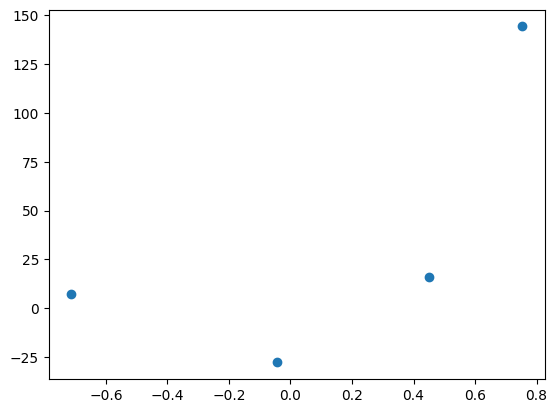

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [5]:
# applying OLS First
from sklearn.linear_model import LinearRegression

In [6]:
reg = LinearRegression()
reg.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
reg.coef_

array([78.35063668])

In [9]:
reg.intercept_

np.float64(26.15963284313262)

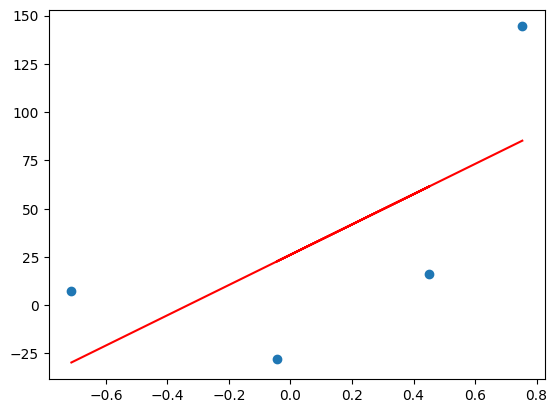

In [10]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color = 'red')

In [11]:
# Applying Gradient Descent  assuming slope is constant m = 78.35
# And assuming the starting value of b is 0
y_pred = ((78.35*x)+0).reshape(4)

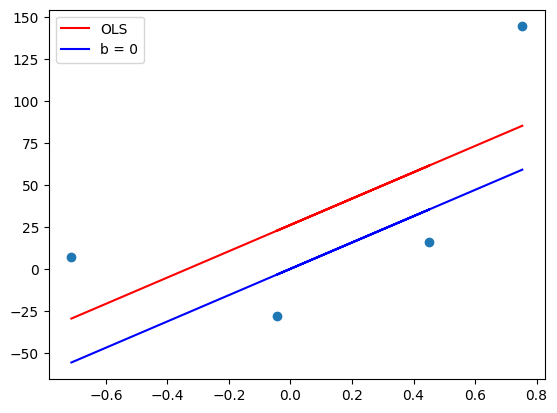

In [12]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color = 'red',label = 'OLS')
plt.plot(x,y_pred,color = 'blue',label = 'b = 0')
plt.legend()
plt.show()

In [20]:
m = 78.35
b = 0
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-209.27763408209216)

In [21]:
# Assuming the learning rate  = 0.1
lr = 0.1
step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [22]:
# Calculating the new intercept
b = b - step_size    # bnew = bold - n*slope  where n is the learning rate
b

np.float64(20.927763408209216)

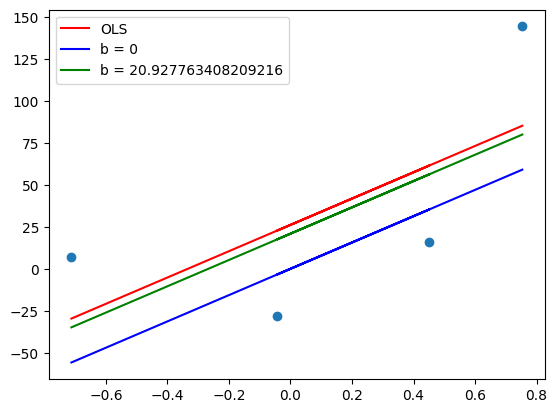

In [23]:
y_pred1 = ((78.35 * x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color = 'red',label = 'OLS')
plt.plot(x,y_pred,color = 'blue',label = 'b = 0')
plt.plot(x,y_pred1,color = 'green',label = 'b = {}'.format(b))
plt.legend()
plt.show()

In [24]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-41.85552681641845)

In [25]:
step_size = loss_slope*lr
step_size

np.float64(-4.185552681641845)

In [26]:
b = b - step_size
b

np.float64(25.11331608985106)

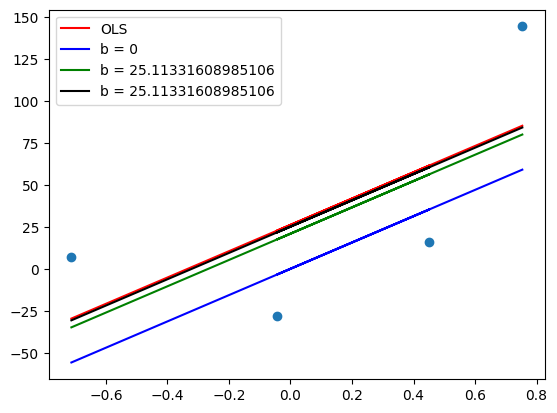

In [27]:
y_pred2 = ((78.35 * x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color = 'red',label = 'OLS')
plt.plot(x,y_pred,color = 'blue',label = 'b = 0')
plt.plot(x,y_pred1,color = 'green',label = 'b = {}'.format(b))
plt.plot(x,y_pred2,color = 'black',label = 'b = {}'.format(b))

plt.legend()
plt.show()

In [28]:
#Iteration 3
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-8.37110536328369)

In [29]:
step_size = loss_slope*lr
step_size

np.float64(-0.837110536328369)

In [30]:
b = b - step_size
b

np.float64(25.95042662617943)

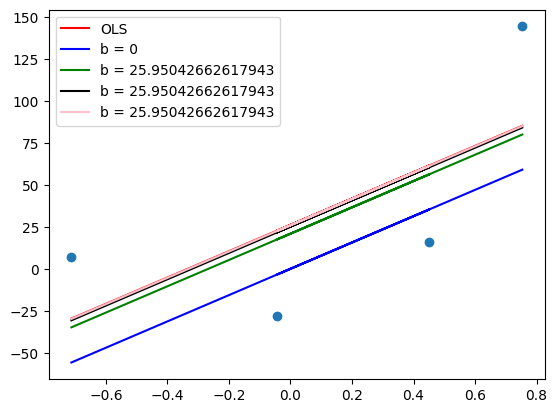

In [31]:
y_pred3 = ((78.35 * x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color = 'red',label = 'OLS')
plt.plot(x,y_pred,color = 'blue',label = 'b = 0')
plt.plot(x,y_pred1,color = 'green',label = 'b = {}'.format(b))
plt.plot(x,y_pred2,color = 'black',label = 'b = {}'.format(b))
plt.plot(x,y_pred3,color = 'pink',label = 'b = {}'.format(b))


plt.legend()
plt.show()

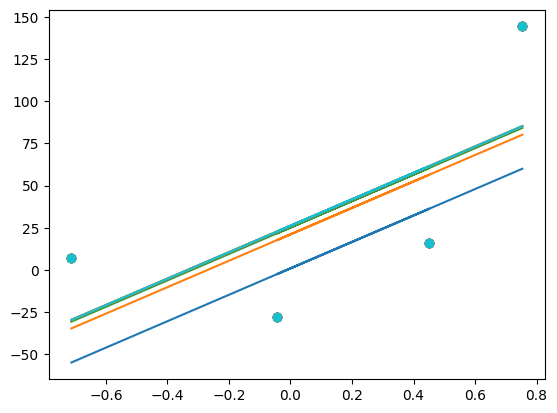

In [32]:
b = -100
m = 78.35
lr = 0.1

epochs = 10 # iterations

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*x.ravel() - b)
    b = b - (lr*loss_slope)
    y_pred = m*x + b

    plt.plot(x,y_pred)
    plt.scatter(x,y)